In [63]:
import pandas as pd
import numpy as np

In [64]:
data = pd.read_csv("../../course_assignments/homework8/state_data.csv")

np.shape(data) # 4 columns, 52 rows

(52, 4)

In [65]:
print(data.head())
# The columns represent the states abbreviated name, latitude of the state, longitude, and the state's name
# The first state is Alaska
# The last state is Wyoming
# There are 52 entries in total

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California


In [66]:
print(data.tail())
# more than 50 entries because this list included D.C. and Puerto Rico

   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


In [67]:
lat_long_mean=data[["latitude", "longitude"]]
print(lat_long_mean.mean())
# Latitude: 39.15
# Longitude: -92.82

latitude     39.153437
longitude   -92.824719
dtype: float64


In [68]:
long_median=data["longitude"].median()
data["abs_median_long"]=(data["longitude"] - long_median).abs()

lat_median=data["latitude"].median()
data["abs_median_lat"]=(data["latitude"] - lat_median).abs()
data.head()
np.shape(data) # 52 rows, 6 columns

(52, 6)

In [69]:
median_lat=data["latitude"].median()
median_long=data["longitude"].median()
data["abs_dist_to_median_lat"]=(data["latitude"]-median_lat).abs()
data["abs_dist_to_median_long"]=(data["longitude"]-median_long).abs()
closest_lat=data["abs_dist_to_median_lat"].idxmin()
farthest_lat=data["abs_dist_to_median_lat"].idxmax()
closest_long=data["abs_dist_to_median_long"].idxmin()
farthest_long=data["abs_dist_to_median_long"].idxmax()

print(f"closest median latitude: {data.loc[closest_lat, 'state']} by {data.loc[closest_lat, 'abs_dist_to_median_lat']:.2f}")
print(f"farthest median latitude: {data.loc[farthest_lat, 'state']} by {data.loc[farthest_lat, 'abs_dist_to_median_lat']:.2f}")
print(f"closest median longitude: {data.loc[closest_long, 'state']} by {data.loc[closest_long, 'abs_dist_to_median_long']:.2f}")
print(f"farthest median longitude: {data.loc[farthest_long, 'state']} by {data.loc[farthest_long, 'abs_dist_to_median_long']:.2f}")

closest median latitude: CO by 0.11
farthest median latitude: AK by 24.15
closest median longitude: IL by 0.31
farthest median longitude: HI by 66.57


In [70]:
new_chart=data.style.highlight_max(color='red').highlight_min(color='green')
new_chart
# found it API reference > style > styler
# this function highlights the min and max values for each column. Can be helpful when you have a really large dataset to visualize specific values quickly

,state,latitude,longitude,name,abs_median_long,abs_median_lat,abs_dist_to_median_lat,abs_dist_to_median_long
0,AK,63.588753,-154.493062,Alaska,65.399864,24.153237,24.153237,65.399864
1,AL,32.318231,-86.902298,Alabama,2.190900,7.117285,7.117285,2.190900
2,AR,35.201050,-91.831833,Arkansas,2.738635,4.234465,4.234465,2.738635
3,AZ,34.048928,-111.093731,Arizona,22.000533,5.386588,5.386588,22.000533
4,CA,36.778261,-119.417932,California,30.324734,2.657255,2.657255,30.324734
5,CO,39.550051,-105.782067,Colorado,16.688869,0.114536,0.114536,16.688869
6,CT,41.603221,-73.087749,Connecticut,16.005449,2.167705,2.167705,16.005449
7,DC,38.905985,-77.033418,District of Columbia,12.059780,0.529530,0.529530,12.059780
8,DE,38.910832,-75.527670,Delaware,13.565528,0.524684,0.524684,13.565528
9,FL,27.664827,-81.515754,Florida,7.577444,11.770689,11.770689,7.577444


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
DataFrame=sns.load_dataset("anagrams")
DataFrame_new=DataFrame.dropna(axis=1)
DataFrame_new.head()
np.shape(DataFrame_new) # shape is 20 rows, 5 columns (20,5)

(20, 5)

In [73]:
print(DataFrame_new.head())
print(DataFrame_new.tail())
# subidir, attnr, num1, num2, num3
# subidir could just be denoting the subject
# attnr is the attention of the participant
# num1... means the number of possible anagram solutions for each anagram and the subjects score

   subidr    attnr  num1  num2  num3
0       1  divided     2   4.0     7
1       2  divided     3   4.0     5
2       3  divided     3   5.0     6
3       4  divided     5   7.0     5
4       5  divided     4   5.0     8
    subidr    attnr  num1  num2  num3
15      16  focused     6   8.0     7
16      17  focused     7   7.0     6
17      18  focused     7   8.0     6
18      19  focused     5   6.0     6
19      20  focused     6   6.0     5


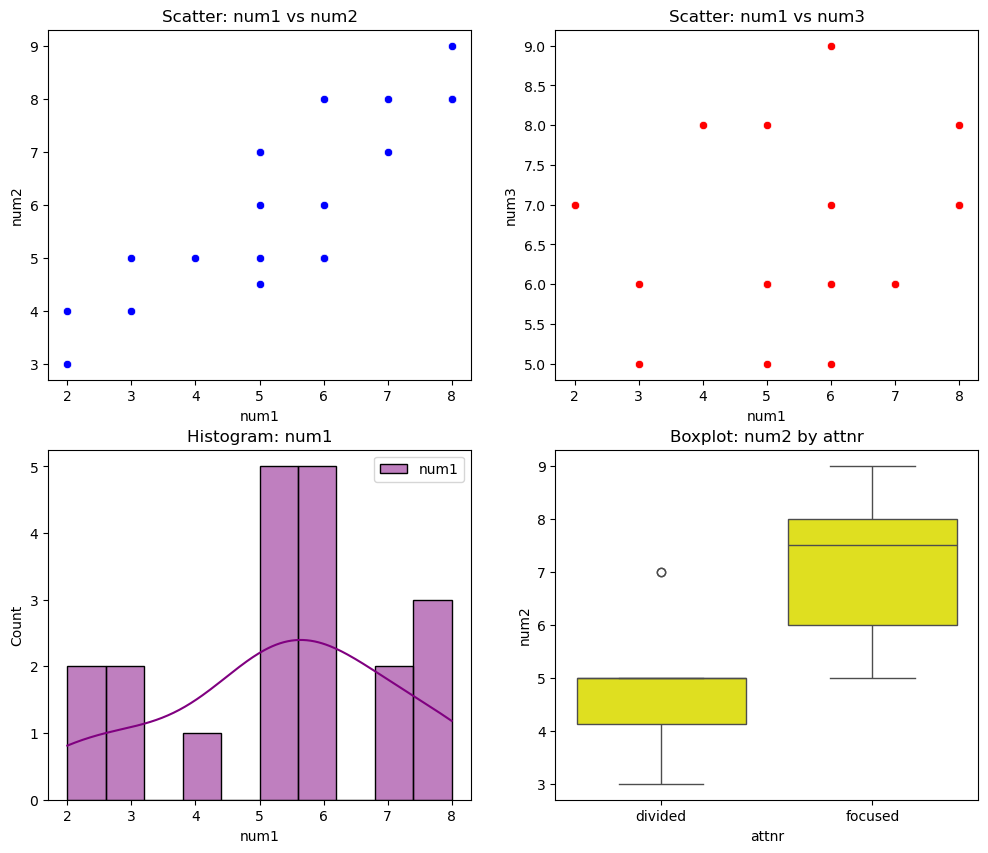

In [74]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

sns.scatterplot(x='num1', y='num2', data=DataFrame_new, ax=axs[0, 0], color="blue")
axs[0, 0].set_title('Scatter: num1 vs num2')
# each point shows a participant and their performance during num1 vs num2. I only had 3 columns of result data so i just chose random ones

sns.scatterplot(x='num1', y='num3', data=DataFrame_new, ax=axs[0, 1], color="red")
axs[0, 1].set_title('Scatter: num1 vs num3')
# compares num 1 vs num 3

sns.histplot(DataFrame_new['num1'], bins=10, kde=True, ax=axs[1, 0], color="purple", label='num1')
axs[1,0].legend()
axs[1, 0].set_title('Histogram: num1')
# shows the distribuion of scores on num 1

sns.boxplot(x='attnr', y='num2', data=DataFrame_new, ax=axs[1, 1], color="yellow")
axs[1, 1].set_title('Boxplot: num2 by attnr')
# num 2 scores separated by their attention during the study

plt.show()